# 🧠 Brain CT Hemorrhage Detection
### Dual-Model AI: SVM + PCA | VGG Neural Network

---
**Run each cell top to bottom. GPU recommended (Runtime → Change runtime type → T4 GPU)**

This notebook:
1. Installs all dependencies
2. Downloads and prepares the dataset
3. Trains SVM + PCA model
4. Trains VGG Neural Network
5. Saves all model files
6. Runs a full prediction demo with visualisation
7. Launches Flask app via ngrok (optional)
---

## Cell 1 — Install dependencies

In [ ]:
# Install all required packages
!pip install -q flask pyngrok opencv-python-headless scikit-learn joblib matplotlib seaborn
!pip install -q tensorflow==2.15.0

import sys
print(f'Python: {sys.version}')

import tensorflow as tf
print(f'TensorFlow: {tf.__version__}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')

import sklearn; print(f'scikit-learn: {sklearn.__version__}')
import cv2;      print(f'OpenCV: {cv2.__version__}')
print('✅ All dependencies installed')

ERROR: Could not find a version that satisfies the requirement tensorflow==2.15.0 (from versions: 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.19.1, 2.20.0rc0, 2.20.0, 2.21.0rc0, 2.21.0rc1, 2.21.0)
ERROR: No matching distribution found for tensorflow==2.15.0
Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
TensorFlow: 2.19.0
GPU available: True
scikit-learn: 1.6.1
OpenCV: 4.13.0
✅ All dependencies installed


## Cell 2 — Imports & folder setup

In [ ]:
import os, cv2, numpy as np, joblib, warnings
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
warnings.filterwarnings('ignore')

from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Dense, Flatten, Dropout, GlobalAveragePooling2D,
    Conv2D, MaxPooling2D, BatchNormalization, Input
)
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import to_categorical

# ── Folder setup ──────────────────────────────────────────
DIRS = [
    'models',
    'dataset/train/Hemorrhagic',
    'dataset/train/NORMAL',
    'dataset/test/Hemorrhagic',
    'dataset/test/NORMAL',
    'static/uploads',
    'templates'
]
for d in DIRS:
    os.makedirs(d, exist_ok=True)

# ── Constants ─────────────────────────────────────────────
SVM_IMG_SIZE  = (90, 90)
VGG_IMG_SIZE  = (150, 150)
CLASSES       = ['Hemorrhagic', 'NORMAL']
TRAIN_DIR     = 'dataset/train'
TEST_DIR      = 'dataset/test'
SEED          = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('✅ Imports complete. Folders created.')

✅ Imports complete. Folders created.


## Cell 3 — Dataset

**Option A (recommended):** Upload your own dataset using the file manager (left sidebar → upload)
and place images in:
- `dataset/train/Hemorrhagic/`
- `dataset/train/NORMAL/`
- `dataset/test/Hemorrhagic/`
- `dataset/test/NORMAL/`

**Option B:** Download from Kaggle (set your credentials below)

**Option C (demo):** Auto-generates synthetic CT-like images so you can test the full pipeline without real data

Existing images: {'train/Hemorrhagic': 0, 'train/NORMAL': 0, 'test/Hemorrhagic': 0, 'test/NORMAL': 0}
Generating synthetic data for demo...
✅ Generated 600 train + 160 test synthetic images


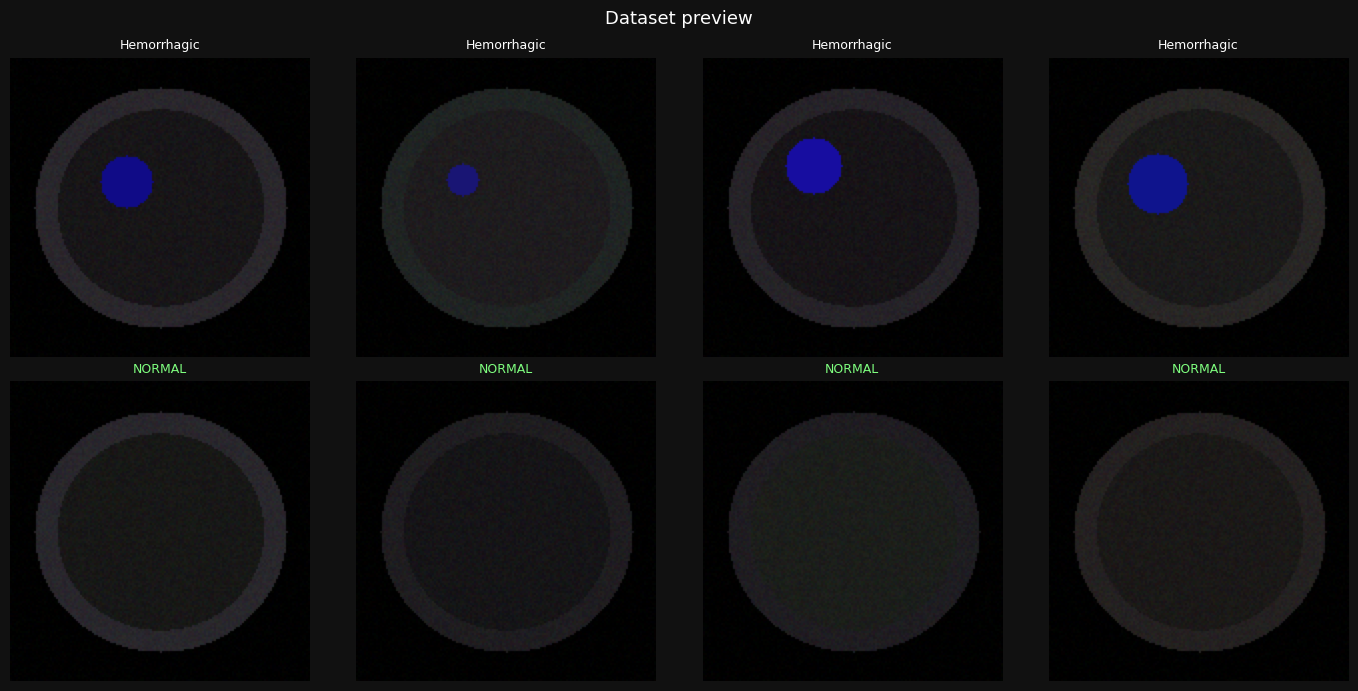

In [ ]:
# ── Option B: Kaggle download (fill in your credentials) ──
USE_KAGGLE = False   # Set True and fill credentials to use

if USE_KAGGLE:
    import json
    kaggle_creds = {"username": "YOUR_USERNAME", "key": "YOUR_API_KEY"}
    os.makedirs('/root/.kaggle', exist_ok=True)
    with open('/root/.kaggle/kaggle.json', 'w') as f:
        json.dump(kaggle_creds, f)
    os.chmod('/root/.kaggle/kaggle.json', 0o600)
    !pip install -q kaggle
    # Example dataset — replace with your dataset slug
    !kaggle datasets download -d felipekitamura/head-ct-hemorrhage -p dataset/ --unzip
    print('✅ Kaggle dataset downloaded')

# ── Option C: Synthetic demo data ─────────────────────────
def make_synthetic_brain(size=150, hemorrhagic=False, seed=0):
    rng = np.random.RandomState(seed)
    img = np.zeros((size, size, 3), dtype=np.uint8)
    cx, cy, rx, ry = size//2, size//2, int(size*0.42), int(size*0.40)
    Y, X = np.ogrid[:size, :size]
    mask = ((X-cx)/rx)**2 + ((Y-cy)/ry)**2 <= 1
    skull_val = rng.randint(30, 45)
    img[mask] = [skull_val + rng.randint(-3, 3) for _ in range(3)]
    inner = ((X-cx)/(rx*0.82))**2 + ((Y-cy)/(ry*0.82))**2 <= 1
    brain_val = rng.randint(20, 30)
    img[inner] = [brain_val + rng.randint(-2, 2) for _ in range(3)]
    noise = rng.randint(-6, 6, img.shape).astype(np.int16)
    img = np.clip(img.astype(np.int16) + noise, 0, 255).astype(np.uint8)
    if hemorrhagic:
        hx = int(cx - rx*0.28 + rng.randint(-8, 8))
        hy = int(cy - ry*0.22 + rng.randint(-8, 8))
        hr = rng.randint(8, 16)
        HY, HX = np.ogrid[:size, :size]
        bleed = (HX-hx)**2 + (HY-hy)**2 <= hr**2
        bleed &= inner
        img[bleed, 0] = rng.randint(100, 180)
        img[bleed, 1] = rng.randint(10, 30)
        img[bleed, 2] = rng.randint(10, 30)
    return img

def check_and_generate_synthetic():
    counts = {}
    for split in ['train', 'test']:
        for cls in CLASSES:
            p = f'dataset/{split}/{cls}'
            n = len([f for f in os.listdir(p) if f.lower().endswith(('.png','.jpg','.jpeg'))])
            counts[f'{split}/{cls}'] = n
    total = sum(counts.values())
    print(f'Existing images: {counts}')
    if total < 20:
        print('Generating synthetic data for demo...')
        N_TRAIN, N_TEST = 300, 80
        for i in range(N_TRAIN):
            hem = make_synthetic_brain(150, hemorrhagic=True,  seed=i)
            nrm = make_synthetic_brain(150, hemorrhagic=False, seed=i+10000)
            cv2.imwrite(f'dataset/train/Hemorrhagic/hem_{i:04d}.png', hem)
            cv2.imwrite(f'dataset/train/NORMAL/nrm_{i:04d}.png',      nrm)
        for i in range(N_TEST):
            hem = make_synthetic_brain(150, hemorrhagic=True,  seed=i+20000)
            nrm = make_synthetic_brain(150, hemorrhagic=False, seed=i+30000)
            cv2.imwrite(f'dataset/test/Hemorrhagic/hem_{i:04d}.png', hem)
            cv2.imwrite(f'dataset/test/NORMAL/nrm_{i:04d}.png',      nrm)
        print(f'✅ Generated {N_TRAIN*2} train + {N_TEST*2} test synthetic images')
    else:
        print('✅ Using existing dataset')

check_and_generate_synthetic()

# ── Preview ────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.patch.set_facecolor('#111')
for row, cls in enumerate(CLASSES):
    imgs = sorted(os.listdir(f'dataset/train/{cls}'))[:4]
    for col, fn in enumerate(imgs):
        ax = axes[row][col]
        img = cv2.imread(f'dataset/train/{cls}/{fn}')
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img, cmap='gray')
        ax.set_title(cls, color='white' if cls=='Hemorrhagic' else '#7fff7f', fontsize=9)
        ax.axis('off')
plt.suptitle('Dataset preview', color='white', fontsize=13)
plt.tight_layout()
plt.show()

## Cell 4 — Load & preprocess data for SVM

Loading SVM training data...
Train: (600, 100) | Test: (160, 100)
Classes: ['Hemorrhagic' 'NORMAL']
PCA variance explained: 56.5%


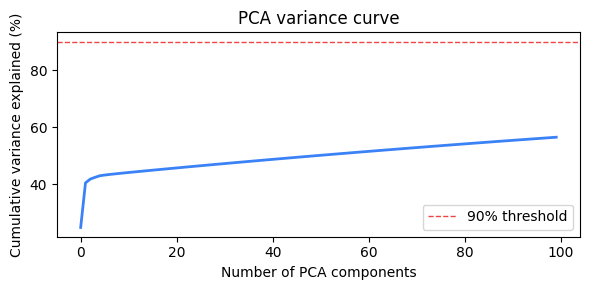

✅ SVM data ready


In [ ]:
def load_images_svm(base_dir, img_size=SVM_IMG_SIZE):
    X, y = [], []
    for cls in CLASSES:
        path = os.path.join(base_dir, cls)
        for fn in os.listdir(path):
            if not fn.lower().endswith(('.png','.jpg','.jpeg')): continue
            img = cv2.imread(os.path.join(path, fn), cv2.IMREAD_GRAYSCALE)
            if img is None: continue
            img = cv2.resize(img, img_size)
            X.append(img.flatten())
            y.append(cls)
    return np.array(X, dtype=np.float32), np.array(y)

print('Loading SVM training data...')
X_train_raw, y_train_raw = load_images_svm(TRAIN_DIR)
X_test_raw,  y_test_raw  = load_images_svm(TEST_DIR)

le = LabelEncoder()
y_train = le.fit_transform(y_train_raw)
y_test  = le.transform(y_test_raw)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_raw)
X_test_sc  = scaler.transform(X_test_raw)

pca = PCA(n_components=100, random_state=SEED)
X_train_pca = pca.fit_transform(X_train_sc)
X_test_pca  = pca.transform(X_test_sc)

print(f'Train: {X_train_pca.shape} | Test: {X_test_pca.shape}')
print(f'Classes: {le.classes_}')
print(f'PCA variance explained: {pca.explained_variance_ratio_.sum()*100:.1f}%')

fig, ax = plt.subplots(figsize=(6, 3))
cumvar = np.cumsum(pca.explained_variance_ratio_) * 100
ax.plot(cumvar, color='#3b82f6', linewidth=2)
ax.axhline(90, color='#ef4444', linestyle='--', linewidth=1, label='90% threshold')
ax.set_xlabel('Number of PCA components')
ax.set_ylabel('Cumulative variance explained (%)')
ax.set_title('PCA variance curve')
ax.legend()
plt.tight_layout()
plt.show()
print('✅ SVM data ready')

## Cell 5 — Train SVM model

Training SVM (this may take 1-2 min)...

=== SVM Results ===
Accuracy: 98.12%

Classification Report:
              precision    recall  f1-score   support

 Hemorrhagic       0.99      0.97      0.98        80
      NORMAL       0.98      0.99      0.98        80

    accuracy                           0.98       160
   macro avg       0.98      0.98      0.98       160
weighted avg       0.98      0.98      0.98       160



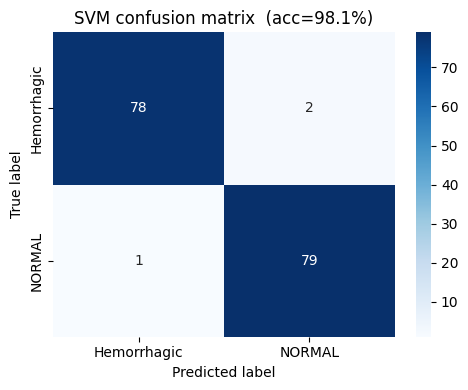

✅ SVM models saved to models/


In [ ]:
print('Training SVM (this may take 1-2 min)...')
svm_model = SVC(
    kernel='linear',
    C=1.0,
    probability=True,
    random_state=SEED
)
svm_model.fit(X_train_pca, y_train)

y_pred_svm = svm_model.predict(X_test_pca)
svm_acc = accuracy_score(y_test, y_pred_svm)

print(f'\n=== SVM Results ===')
print(f'Accuracy: {svm_acc*100:.2f}%')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_svm, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred_svm)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_title(f'SVM confusion matrix  (acc={svm_acc*100:.1f}%)')
ax.set_ylabel('True label')
ax.set_xlabel('Predicted label')
plt.tight_layout()
plt.show()

# Save
joblib.dump(svm_model, 'models/svm_model_linear_pca.pkl')
joblib.dump(scaler,    'models/scaler.pkl')
joblib.dump(pca,       'models/pca.pkl')
joblib.dump(le,        'models/label_encoder.pkl')
print('✅ SVM models saved to models/')

## Cell 6 — Build & train VGG model

In [ ]:
# ── Data generators ──────────────────────────────────────
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    validation_split=0.15
)
test_gen = ImageDataGenerator(rescale=1./255)

train_flow = train_gen.flow_from_directory(
    TRAIN_DIR, target_size=VGG_IMG_SIZE,
    batch_size=16, class_mode='categorical',
    subset='training', seed=SEED
)
val_flow = train_gen.flow_from_directory(
    TRAIN_DIR, target_size=VGG_IMG_SIZE,
    batch_size=16, class_mode='categorical',
    subset='validation', seed=SEED
)
test_flow = test_gen.flow_from_directory(
    TEST_DIR, target_size=VGG_IMG_SIZE,
    batch_size=16, class_mode='categorical',
    shuffle=False
)

CLASS_NAMES_VGG = list(train_flow.class_indices.keys())
print(f'VGG class order: {CLASS_NAMES_VGG}')

# ── VGG16 transfer learning model ────────────────────────
base = VGG16(weights='imagenet', include_top=False,
             input_shape=(*VGG_IMG_SIZE, 3))
# Unfreeze top 4 conv layers for fine-tuning
for layer in base.layers[:-4]:
    layer.trainable = False
for layer in base.layers[-4:]:
    layer.trainable = True

x = base.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
out = Dense(len(CLASS_NAMES_VGG), activation='softmax')(x)

vgg_model = Model(inputs=base.input, outputs=out)
vgg_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

trainable_count = sum(1 for l in vgg_model.layers if l.trainable)
print(f'Trainable layers: {trainable_count} / {len(vgg_model.layers)}')

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=8,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=4, min_lr=1e-7, verbose=1),
    ModelCheckpoint('models/best_vgg.keras', monitor='val_accuracy',
                    save_best_only=True, verbose=0)
]

print('\nTraining VGG model...')
history = vgg_model.fit(
    train_flow,
    epochs=30,
    validation_data=val_flow,
    callbacks=callbacks,
    verbose=1
)
print('✅ VGG training complete')

Found 510 images belonging to 2 classes.
Found 90 images belonging to 2 classes.
Found 160 images belonging to 2 classes.
VGG class order: ['Hemorrhagic', 'NORMAL']
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Trainable layers: 11 / 26

Training VGG model...
Epoch 1/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 34s 527ms/step - accuracy: 0.9745 - loss: 0.0792 - val_accuracy: 1.0000 - val_loss: 0.1846 - learning_rate: 1.0000e-04
Epoch 2/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 138ms/step - accuracy: 1.0000 - loss: 0.0083 - val_accuracy: 1.0000 - val_loss: 0.1202 - learning_rate: 1.0000e-04
Epoch 3/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 134ms/step - accuracy: 1.0000 - loss: 0.0042 - val_accuracy: 1.0000 - val_loss: 0.0609 - learning_rate: 1.0000e-04
Epoch 4/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 161ms/step - accuracy: 1.0000 - loss: 0.0022 - val_accuracy: 1.0000 - val_loss: 0.0288 - learning_rate: 1.0000e-04
Epoch 5/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 132ms/step - accuracy: 1.0000 - loss: 0.0028 - val_accuracy: 1.0000 -

## Cell 7 — Evaluate VGG & plot training curves

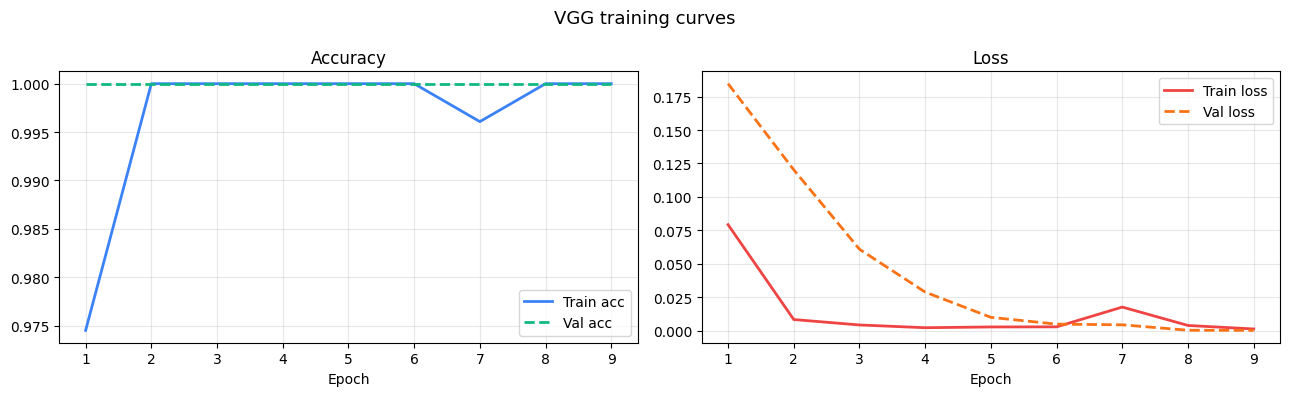


=== VGG Test Results ===
Accuracy: 100.00%  |  Loss: 0.1726

Classification Report:
              precision    recall  f1-score   support

 Hemorrhagic       1.00      1.00      1.00        80
      NORMAL       1.00      1.00      1.00        80

    accuracy                           1.00       160
   macro avg       1.00      1.00      1.00       160
weighted avg       1.00      1.00      1.00       160



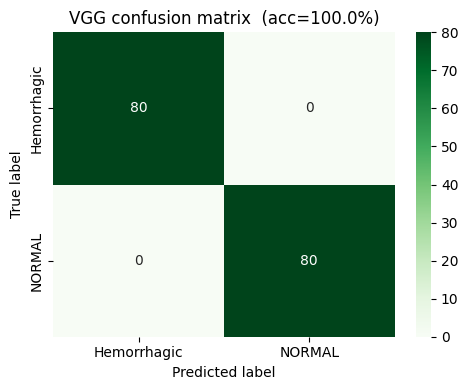

In [ ]:
# Training history plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ep = range(1, len(history.history['accuracy']) + 1)
ax1.plot(ep, history.history['accuracy'],     color='#3b82f6', label='Train acc',  linewidth=2)
ax1.plot(ep, history.history['val_accuracy'], color='#10b981', label='Val acc',    linewidth=2, linestyle='--')
ax1.set_title('Accuracy'); ax1.set_xlabel('Epoch'); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(ep, history.history['loss'],         color='#ef4444', label='Train loss', linewidth=2)
ax2.plot(ep, history.history['val_loss'],     color='#f97316', label='Val loss',   linewidth=2, linestyle='--')
ax2.set_title('Loss');     ax2.set_xlabel('Epoch'); ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle('VGG training curves', fontsize=13)
plt.tight_layout()
plt.show()

# Test evaluation
test_loss, test_acc = vgg_model.evaluate(test_flow, verbose=0)
print(f'\n=== VGG Test Results ===')
print(f'Accuracy: {test_acc*100:.2f}%  |  Loss: {test_loss:.4f}')

y_pred_probs = vgg_model.predict(test_flow, verbose=0)
y_pred_vgg   = np.argmax(y_pred_probs, axis=1)
y_true_vgg   = test_flow.classes

print('\nClassification Report:')
print(classification_report(y_true_vgg, y_pred_vgg, target_names=CLASS_NAMES_VGG))

cm_vgg = confusion_matrix(y_true_vgg, y_pred_vgg)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_vgg, annot=True, fmt='d', cmap='Greens',
            xticklabels=CLASS_NAMES_VGG, yticklabels=CLASS_NAMES_VGG, ax=ax)
ax.set_title(f'VGG confusion matrix  (acc={test_acc*100:.1f}%)')
ax.set_ylabel('True label')
ax.set_xlabel('Predicted label')
plt.tight_layout()
plt.show()

## Cell 8 — Save VGG model files

In [ ]:
# Save in the exact format expected by app.py
model_json = vgg_model.to_json()
with open('models/model_vgg.json', 'w') as f:
    f.write(model_json)

vgg_model.save_weights('models/model_vgg.weights.h5')

# Also save full keras model as backup
vgg_model.save('models/model_vgg_full.keras')

# Verify all files exist
required = [
    'models/svm_model_linear_pca.pkl',
    'models/scaler.pkl',
    'models/pca.pkl',
    'models/label_encoder.pkl',
    'models/model_vgg.json',
    'models/model_vgg.weights.h5'
]
print('Model files:')
all_ok = True
for f in required:
    exists = os.path.exists(f)
    size   = os.path.getsize(f)/1024 if exists else 0
    status = '✅' if exists else '❌'
    print(f'  {status} {f}  ({size:.1f} KB)')
    if not exists: all_ok = False

print(f'\n{"✅ All model files saved!" if all_ok else "❌ Some files missing!"}')

Model files:
  ✅ models/svm_model_linear_pca.pkl  (84.1 KB)
  ✅ models/scaler.pkl  (190.4 KB)
  ✅ models/pca.pkl  (3197.8 KB)
  ✅ models/label_encoder.pkl  (0.4 KB)
  ✅ models/model_vgg.json  (23.1 KB)
  ✅ models/model_vgg.weights.h5  (114806.6 KB)

✅ All model files saved!


## Cell 9 — Full prediction demo (no Flask needed)

Models loaded


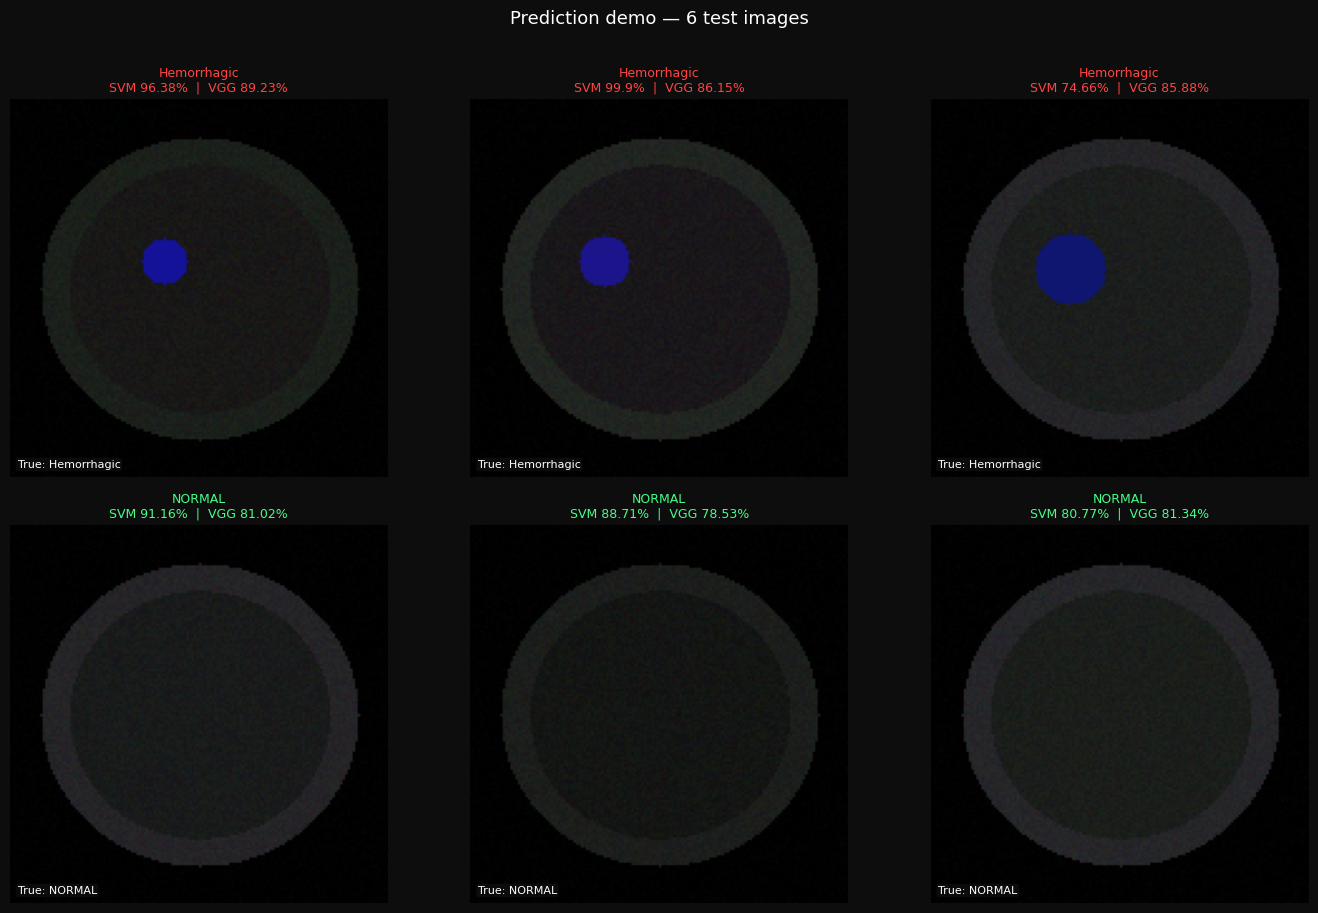

✅ Prediction demo complete


In [ ]:
# ── Reload models fresh (simulates what app.py does) ──────
import joblib
from tensorflow.keras.models import model_from_json

_svm   = joblib.load('models/svm_model_linear_pca.pkl')
_sc    = joblib.load('models/scaler.pkl')
_pca   = joblib.load('models/pca.pkl')
_le    = joblib.load('models/label_encoder.pkl')

with open('models/model_vgg.json') as f:
    _vgg = model_from_json(f.read())
_vgg.load_weights('models/model_vgg.weights.h5')
print('Models loaded')

def predict_image(image_path):
    # SVM
    gray = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    gray = cv2.resize(gray, SVM_IMG_SIZE).flatten().reshape(1, -1)
    gray = _pca.transform(_sc.transform(gray))
    svm_pred = _le.inverse_transform([int(_svm.predict(gray)[0])])[0]
    svm_conf = round(float(np.max(_svm.predict_proba(gray))) * 100, 2)

    # VGG
    rgb = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
    rgb = cv2.resize(rgb, VGG_IMG_SIZE) / 255.0
    probs   = _vgg.predict(np.expand_dims(rgb, 0), verbose=0)[0]
    vgg_idx  = int(np.argmax(probs))
    vgg_pred = CLASS_NAMES_VGG[vgg_idx]
    vgg_conf = round(float(np.max(probs)) * 100, 2)

    overall  = 'Hemorrhagic' if 'em' in svm_pred.lower() or 'em' in vgg_pred.lower() else 'NORMAL'
    avg_conf = round((svm_conf + vgg_conf) / 2, 2)

    return dict(svm_class=svm_pred, svm_conf=svm_conf,
                vgg_class=vgg_pred, vgg_conf=vgg_conf,
                overall=overall,   avg_conf=avg_conf,
                agree=(svm_pred==vgg_pred))

# Test on 6 sample images (3 hemorrhagic, 3 normal)
samples = []
for cls in CLASSES:
    imgs = sorted(os.listdir(f'dataset/test/{cls}'))[:3]
    for fn in imgs:
        samples.append((f'dataset/test/{cls}/{fn}', cls))

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
fig.patch.set_facecolor('#0d0d0d')

for idx, (path, true_cls) in enumerate(samples[:6]):
    row, col = divmod(idx, 3)
    r = predict_image(path)
    ax = axes[row][col]
    img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.axis('off')

    color = '#ff4444' if r['overall']=='Hemorrhagic' else '#44ff88'
    title = f"{r['overall']}\nSVM {r['svm_conf']}%  |  VGG {r['vgg_conf']}%"
    border_color = '#ff4444' if r['overall']=='Hemorrhagic' else '#44ff88'
    for spine in ax.spines.values():
        spine.set_edgecolor(border_color)
        spine.set_linewidth(2.5)
        spine.set_visible(True)
    ax.set_title(title, color=color, fontsize=9, pad=6)
    ax.text(0.02, 0.02, f'True: {true_cls}', transform=ax.transAxes,
            color='white', fontsize=8, va='bottom',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='#111', alpha=0.7))

plt.suptitle('Prediction demo — 6 test images', color='white', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()
print('✅ Prediction demo complete')

## Cell 10 — Download model files to your computer

In [ ]:
import zipfile
from google.colab import files

with zipfile.ZipFile('trained_models.zip', 'w', zipfile.ZIP_DEFLATED) as zf:
    for fn in required:
        zf.write(fn)

size_mb = os.path.getsize('trained_models.zip') / (1024*1024)
print(f'trained_models.zip  ({size_mb:.1f} MB)')
print('Downloading...')
files.download('trained_models.zip')
print('✅ Done — extract into your project models/ folder then run: python app.py')

trained_models.zip  (103.9 MB)
Downloading...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Done — extract into your project models/ folder then run: python app.py


## Cell 11 — (Optional) Launch Flask app via ngrok
Get a free ngrok token from https://dashboard.ngrok.com/signup

In [ ]:
LAUNCH_FLASK = False   # Set True to launch the web app
NGROK_TOKEN  = ''      # Paste your ngrok authtoken here

if LAUNCH_FLASK:
    if not NGROK_TOKEN:
        raise ValueError('Set your NGROK_TOKEN above')

    from pyngrok import ngrok, conf
    conf.get_default().auth_token = NGROK_TOKEN

    # Write index.html
    INDEX_HTML = '''<!DOCTYPE html>
<html><head><meta charset="UTF-8"><title>Brain CT Detection</title>
<style>body{font-family:system-ui;background:#f0f2f5;display:flex;align-items:center;justify-content:center;min-height:100vh;margin:0}
.box{background:#fff;padding:2rem;border-radius:16px;max-width:480px;width:90%;box-shadow:0 2px 8px rgba(0,0,0,.1)}
h2{margin:0 0 .5rem;font-size:1.4rem}p{color:#6b7280;font-size:.9rem;margin-bottom:1.5rem}
.zone{border:2px dashed #d1d5db;border-radius:12px;padding:2rem;text-align:center;cursor:pointer;margin-bottom:1rem}
.zone:hover{background:#f9fafb;border-color:#3b82f6}
button{width:100%;padding:12px;background:#111;color:#fff;border:none;border-radius:8px;font-size:1rem;cursor:pointer}
button:disabled{opacity:.4}</style></head>
<body><div class="box">
<h2>Brain CT Hemorrhage Detection</h2>
<p>Upload a brain CT scan to classify it using SVM + VGG models</p>
<form action="/predict" method="POST" enctype="multipart/form-data">
<div class="zone" onclick="document.getElementById('f').click()">Click to upload CT image</div>
<input id="f" type="file" name="image" accept="image/*" style="display:none" required>
<button type="submit">Analyze</button></form></div></body></html>'''

    RESULT_HTML = '''<!DOCTYPE html>
<html><head><meta charset="UTF-8"><title>Result</title>
<style>body{font-family:system-ui;background:#f0f2f5;min-height:100vh;padding:2rem 1rem}
.box{background:#fff;padding:1.5rem;border-radius:16px;max-width:520px;margin:0 auto;box-shadow:0 2px 8px rgba(0,0,0,.1)}
.hem{background:#fef2f2;border:1px solid #fecaca;border-radius:10px;padding:1rem;margin-bottom:1rem}
.nrm{background:#f0fdf4;border:1px solid #bbf7d0;border-radius:10px;padding:1rem;margin-bottom:1rem}
h3{margin:0 0 4px}p{margin:0;font-size:.85rem;color:#6b7280}
img{width:100%;border-radius:8px;margin:1rem 0;background:#000}
table{width:100%;border-collapse:collapse;font-size:.9rem}
td{padding:8px;border-bottom:1px solid #f3f4f6}
a{display:block;text-align:center;margin-top:1rem;color:#3b82f6}</style></head>
<body><div class="box">
{%- if overall == "Hemorrhagic" %}<div class="hem"><h3 style="color:#7f1d1d">Hemorrhagic Detected</h3><p>Abnormal pattern found</p></div>
{%- else %}<div class="nrm"><h3 style="color:#14532d">No Hemorrhage</h3><p>Scan appears normal</p></div>{%- endif %}
<img src="{{ url_for('static', filename='uploads/' + image) }}" alt="CT scan">
<table><tr><td>SVM prediction</td><td><strong>{{ svm_class }}</strong> ({{ svm_conf }}%)</td></tr>
<tr><td>VGG prediction</td><td><strong>{{ gan_class }}</strong> ({{ gan_conf }}%)</td></tr>
<tr><td>Average confidence</td><td><strong>{{ avg_conf }}%</strong></td></tr>
<tr><td>Models agree</td><td>{{ "Yes" if models_agree else "No" }}</td></tr></table>
<a href="/">Analyze another scan</a></div></body></html>'''

    os.makedirs('templates', exist_ok=True)
    with open('templates/index.html',  'w') as f: f.write(INDEX_HTML)
    with open('templates/result.html', 'w') as f: f.write(RESULT_HTML)

    # Write & run Flask app in background
    FLASK_CODE = '''
from flask import Flask, render_template, request
import os, cv2, numpy as np, joblib
from tensorflow.keras.models import model_from_json
from tensorflow.keras.preprocessing.image import img_to_array
from werkzeug.utils import secure_filename

app = Flask(__name__)
app.config["UPLOAD_FOLDER"] = "static/uploads"
os.makedirs(app.config["UPLOAD_FOLDER"], exist_ok=True)

svm_model = joblib.load("models/svm_model_linear_pca.pkl")
scaler    = joblib.load("models/scaler.pkl")
pca       = joblib.load("models/pca.pkl")
le        = joblib.load("models/label_encoder.pkl")
with open("models/model_vgg.json") as f:
    gan_model = model_from_json(f.read())
gan_model.load_weights("models/model_vgg.weights.h5")

@app.route("/")
def index(): return render_template("index.html")

@app.route("/predict", methods=["POST"])
def predict():
    try:
        file = request.files["image"]
        filename = secure_filename(file.filename)
        path = os.path.join(app.config["UPLOAD_FOLDER"], filename)
        file.save(path)
        gray = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        gray = cv2.resize(gray, (90,90)).flatten().reshape(1,-1)
        gray = pca.transform(scaler.transform(gray))
        svm_pred = le.inverse_transform([int(svm_model.predict(gray)[0])])[0]
        svm_conf = round(float(np.max(svm_model.predict_proba(gray)))*100, 2)
        rgb = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
        rgb = cv2.resize(rgb, (150,150)) / 255.0
        probs = gan_model.predict(np.expand_dims(rgb,0), verbose=0)[0]
        class_names = ["Hemorrhagic","NORMAL"]
        gan_pred = class_names[int(np.argmax(probs[:2]))]
        gan_conf = round(float(np.max(probs[:2]))*100, 2)
        overall  = "Hemorrhagic" if "em" in svm_pred.lower() or "em" in gan_pred.lower() else "NORMAL"
        return render_template("result.html", image=filename,
            svm_class=svm_pred, svm_conf=svm_conf,
            gan_class=gan_pred, gan_conf=gan_conf,
            overall=overall, avg_conf=round((svm_conf+gan_conf)/2,2),
            models_agree=(svm_pred==gan_pred))
    except Exception as e:
        return render_template("index.html", error=str(e))

if __name__ == "__main__":
    app.run(port=5000)
'''
    with open('colab_app.py', 'w') as f: f.write(FLASK_CODE)

    import threading
    t = threading.Thread(target=lambda: os.system('python colab_app.py'), daemon=True)
    t.start()

    import time; time.sleep(3)
    tunnel = ngrok.connect(5000)
    print(f'\n🌐 Flask app running at: {tunnel.public_url}')
    print('Open the URL above to use the web interface')
else:
    print('LAUNCH_FLASK is False — set it to True and add your ngrok token to launch the web app')

LAUNCH_FLASK is False — set it to True and add your ngrok token to launch the web app


---
## ✅ Complete!

| Step | What was done |
|------|---------------|
| Cell 1-2 | Installed dependencies, set up folders |
| Cell 3 | Loaded / generated dataset |
| Cell 4-5 | Trained SVM + PCA model |
| Cell 6-7 | Trained VGG neural network with transfer learning |
| Cell 8 | Saved all 6 model files |
| Cell 9 | Ran prediction demo with visualisation |
| Cell 10 | Downloaded `trained_models.zip` |
| Cell 11 | (Optional) Launched Flask app via ngrok |

**To use locally:** Extract `trained_models.zip` into your project's `models/` folder and run `python app.py`